# Analysis of mutations

In [1]:
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import combinations

# from scipy.stats import linregress
# from matplotlib_venn import venn2
# from tqdm import tqdm
# tqdm.pandas()

In [2]:
all_mutrates = pd.read_table(f"all_mutdensities.tsv")
all_mutrates["DEPTH_log"] = np.log10(all_mutrates["DEPTH"] + 1e-3)

In [3]:
full_cohort_metadata = pd.read_table("20250516_metadata_bladder.with_depths.tsv")
full_cohort_metadata.head()

,SAMPLE_ID,SUBJECT_ID,AGE,SEX,BMI,SMOKING_STATUS,HISTORY_OF_SMOKING,CURRENT_SMOKER,ALCOHOL_GROUP,HISTORY_OF_DRINKING,...,NOTCH2_depth,FOXQ1_depth,CDKN1A_depth,KMT2C_depth,TP53_depth,RB1_depth,FGFR3_depth,PIK3CA_depth,TERTpromoter_depth,total_depth
0,P19_0047_BDO_01,P19_0047,46,M,29.9,former,yes,no,former,yes,...,6866.809023,4604.716364,12537.872222,8061.174839,10219.111423,7411.275842,10154.727518,8533.763889,1217.225989,7219.964358
1,P19_0009_BTR_01,P19_0009,56,F,32.8,current,yes,yes,heavy,yes,...,3582.336286,20081.660000,22902.629630,3906.232083,9616.333567,3643.054758,19295.271583,2809.628472,2877.779661,8327.585211
2,P19_0008_BDO_01,P19_0008,72,M,28.3,former,yes,no,occasional,yes,...,5380.276086,2035.886364,4938.668519,6636.928112,5494.578136,4971.831625,2959.359712,5894.118056,1441.333333,4372.224383
3,P19_0001_BTR_01,P19_0001,24,M,30.1,never,no,no,no,no,...,6541.577498,2180.124545,7210.483333,7638.135789,6367.466713,5440.150512,3755.018885,6841.708333,490.768362,5105.737962
4,P19_0041_BDO_01,P19_0041,59,F,52.7,never,no,no,NaN,NaN,...,4657.111403,2385.021818,5453.885185,5192.524296,4991.056762,5017.462665,4003.279676,5407.927083,1000.299435,4480.454219


In [7]:
subset_mutrates = all_mutrates[(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]
subset_mutrates_annotated = subset_mutrates.merge(full_cohort_metadata, on='SAMPLE_ID')
subset_mutrates_annotated.head()

,SAMPLE_ID,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSRATE_MB,...,NOTCH2_depth,FOXQ1_depth,CDKN1A_depth,KMT2C_depth,TP53_depth,RB1_depth,FGFR3_depth,PIK3CA_depth,TERTpromoter_depth,total_depth
0,P19_0007_BTR_01,ALL_GENES,all,SNV,553100541,241.0,275.0,0.435725,0.435725,0.497197,...,4472.958068,3004.605455,4551.298148,6139.920124,6555.826910,3965.061786,5519.119604,4985.871528,2621.920904,4573.389682
1,P19_0046_BTR_01,ALL_GENES,all,SNV,310723023,267.0,453.0,0.859286,0.859286,1.457890,...,2289.982701,10447.936364,6623.488889,3074.234080,1752.609671,3565.864422,5184.281475,2404.562500,299.774011,3142.133921
2,P19_0013_BTR_01,ALL_GENES,all,SNV,455742968,116.0,118.0,0.254529,0.254529,0.258918,...,3721.398699,1620.313636,4136.350000,4643.565565,3830.855641,4031.235139,2247.937050,4765.697917,353.288136,3516.711544
3,P19_0020_BTR_01,ALL_GENES,all,SNV,873942970,344.0,368.0,0.393618,0.393618,0.421080,...,7165.314974,3238.576364,6287.809259,8243.621034,7790.384022,6438.402050,5497.611511,8139.201389,1244.661017,6601.966740
4,P19_0009_BDO_01,ALL_GENES,all,SNV,498473418,469.0,1358.0,0.940873,0.940873,2.724318,...,3665.422225,1344.500909,3917.446296,4352.411360,5027.231955,3437.712445,3484.423561,3944.923611,512.870056,3675.478613


### Relationship with depth

In [8]:
subset_mutrates_all = all_mutrates[(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]

geness = [ 'ARID1A', 'CDKN1A', 'CREBBP',
          'EP300', 'FGFR3', 'FOXQ1', 'KDM6A',
          'KMT2C', 'KMT2D', 'NOTCH2', 'PIK3CA',
          'RB1', 'RBM10', 'STAG2',
          'TERTpromoter',
          'TP53']

# geness = [ #'ARID1A', 'CDKN1A', 'CREBBP',
#         #   'EP300', 'FGFR3',
#           'FOXQ1',
#         #   'KDM6A',
#         #   'KMT2C', 'KMT2D',
#         'NOTCH2',
#           'PIK3CA',
#         #   'RB1',
#         'RBM10',
#         #'STAG2',
#           'TERTpromoter',
#           'TP53']

subset_mutrates_sel = all_mutrates[~(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               (all_mutrates["GENE"].isin(geness)) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]

subset_mutrates_nosel = all_mutrates[~(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               ~(all_mutrates["GENE"].isin(geness)) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]
# subset_mutrates_annotated = subset_mutrates.merge(full_cohort_metadata, on='SAMPLE_ID')
# subset_mutrates_annotated.head()

In [9]:
mean_coverage_per_gene = subset_mutrates_sel.groupby(by = ["GENE"])["DEPTH"].mean().sort_values()
mean_coverage_per_gene

GENE
TERTpromoter    6.012069e+05
PIK3CA          2.681660e+06
CDKN1A          6.822998e+06
FOXQ1           7.253730e+06
FGFR3           1.015503e+07
TP53            1.955539e+07
RBM10           2.998864e+07
KDM6A           3.578018e+07
STAG2           3.884704e+07
RB1             3.890524e+07
KMT2C           3.956036e+07
ARID1A          6.264907e+07
NOTCH2          6.511117e+07
CREBBP          6.787083e+07
EP300           7.153326e+07
KMT2D           1.449789e+08
Name: DEPTH, dtype: float64

In [10]:
genes_list = []
i = 0
max_val = mean_coverage_per_gene.max()
while 10**i < max_val:
    genes_in_range = mean_coverage_per_gene[(mean_coverage_per_gene >= 10**i) & (mean_coverage_per_gene < 10**(i+1))].index.tolist()
    if len(genes_in_range) > 0:
        genes_list.append((10**i, genes_in_range))
    i += 1
genes_list

[(100000, ['TERTpromoter']),
 (1000000, ['PIK3CA', 'CDKN1A', 'FOXQ1']),
 (10000000,
  ['FGFR3',
   'TP53',
   'RBM10',
   'KDM6A',
   'STAG2',
   'RB1',
   'KMT2C',
   'ARID1A',
   'NOTCH2',
   'CREBBP',
   'EP300']),
 (100000000, ['KMT2D'])]

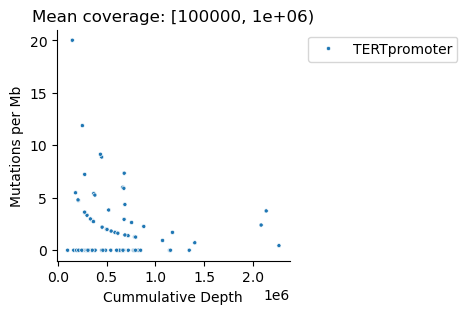

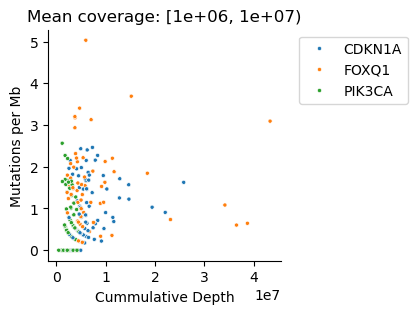

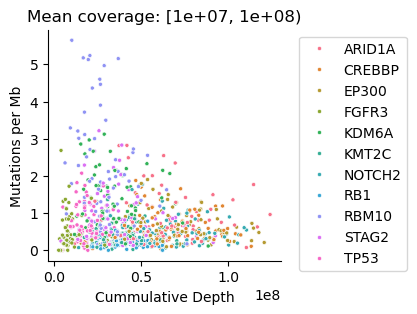

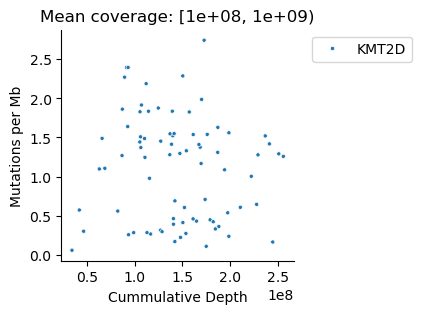

In [11]:
for coverage_range, genes in genes_list:
    df = subset_mutrates_sel[subset_mutrates_sel["GENE"].isin(genes)]
    plt.figure(figsize = (3,3))
    sns.scatterplot(data = df,
                    x = "DEPTH",
                    y = "MUTDENSITY_MB",
                    hue = "GENE",
                    marker = '.',
                    )
    plt.title(f"Mean coverage: [{coverage_range:g}, {coverage_range*10:g})")
    plt.xlabel("Cummulative Depth")
    plt.ylabel("Mutations per Mb")
    sns.despine()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(f'../../figures/extra/mutdensity_age_deepcsa_depthrange_{len(str(coverage_range))}.png', bbox_inches = 'tight', dpi = 300)
    plt.show()

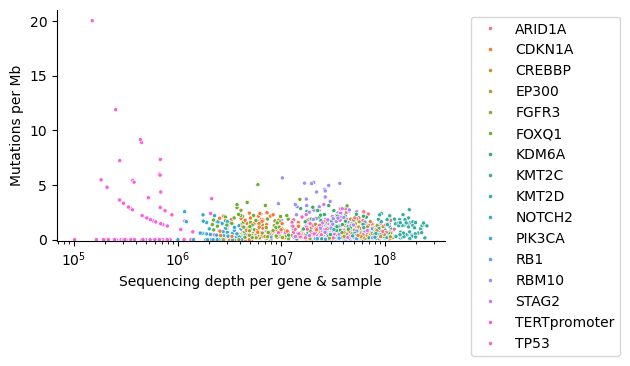

In [12]:
plt.figure(figsize = (5,3))
sns.scatterplot(data = subset_mutrates_sel,
                x = "DEPTH",
                y = "MUTDENSITY_MB",
                hue = "GENE",
                marker = '.'
               )
# plt.yscale('log')
plt.xscale('log')
# plt.xlim(-100, 0.1e8)

bottom, top = plt.ylim()
plt.ylim(-0.1, top)
sns.despine()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Sequencing depth per gene & sample")
plt.ylabel("Mutations per Mb")
plt.savefig('../../figures/extra/mutdensity_depth_selected_genes.png', bbox_inches = 'tight', dpi = 300)

plt.show()

<Figure size 200x100 with 0 Axes>

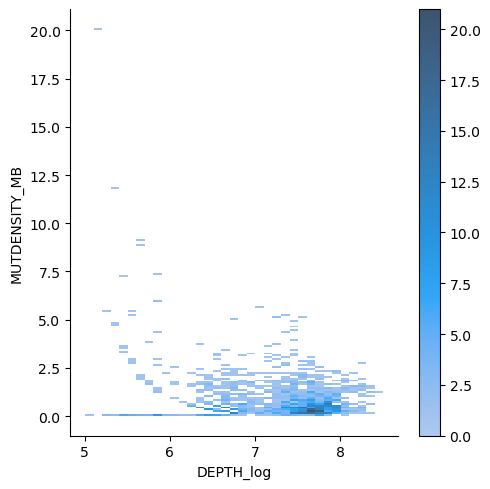

In [18]:
plt.figure(figsize = (2, 1))
sns.displot(data = subset_mutrates_sel,
                x = "DEPTH_log",
                y = "MUTDENSITY_MB",
                # hue = "Protein_affecting",
                binwidth=(.1, .1),
                cbar=True
               )
plt.show()

<Figure size 200x100 with 0 Axes>

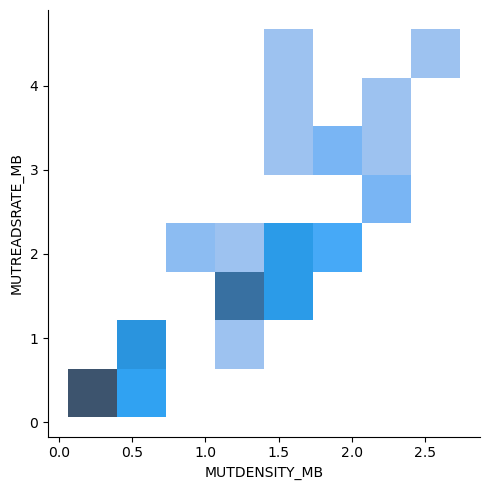

In [19]:
plt.figure(figsize = (2, 1))
sns.displot(data = df,
                x = "MUTDENSITY_MB",
                y = "MUTREADSRATE_MB",
                #hue = "Protein_affecting",
                # binwidth=(.0001, .0001),
                # cbar=True
               )
plt.show()

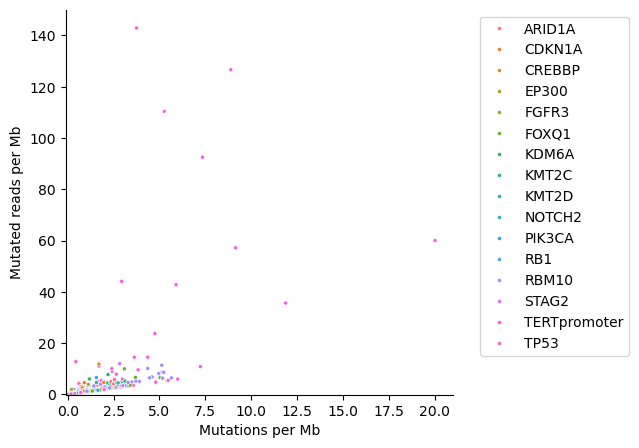

In [23]:
plt.figure(figsize = (5, 5))
sns.scatterplot(data = subset_mutrates_sel,
                x = "MUTDENSITY_MB",
                y = "MUTREADSRATE_MB",
                hue = "GENE",
                marker = '.'
               )

bottom, top = plt.ylim()
plt.ylim(-0.1, top)

bottom, top = plt.xlim()
plt.xlim(-0.1, top)

sns.despine()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Mutations per Mb")
plt.ylabel("Mutated reads per Mb")
plt.savefig('../../figures/extra/mutdensity_vs_mutreads_selected_genes_unrestricted.png', bbox_inches = 'tight', dpi = 300)

plt.show()

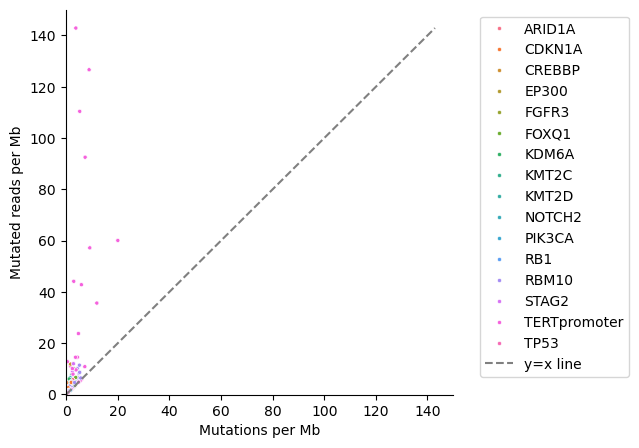

In [25]:
plt.figure(figsize = (5, 5))
sns.scatterplot(data = subset_mutrates_sel,
                x = "MUTDENSITY_MB",
                y = "MUTREADSRATE_MB",
                hue = "GENE",
                marker = '.'
               )

# plot x = y line
max_val = max(subset_mutrates_sel["MUTDENSITY_MB"].max(), subset_mutrates_sel["MUTREADSRATE_MB"].max())
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', label='y=x line')

bottom, top = plt.ylim()
plt.ylim(-0.1, top)

bottom, top = plt.xlim()
plt.xlim(-0.1, top)

sns.despine()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Mutations per Mb")
plt.ylabel("Mutated reads per Mb")
plt.savefig('../../figures/extra/mutdensity_vs_mutreads_selected_genes_unrestricted_equal.png', bbox_inches = 'tight', dpi = 300)

plt.show()

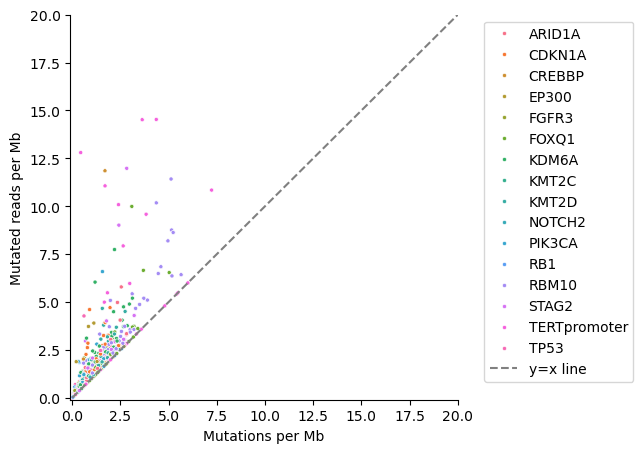

In [26]:
plt.figure(figsize = (5, 5))
sns.scatterplot(data = subset_mutrates_sel,
                x = "MUTDENSITY_MB",
                y = "MUTREADSRATE_MB",
                hue = "GENE",
                marker = '.'
               )

# plot x = y line
max_val = max(subset_mutrates_sel["MUTDENSITY_MB"].max(), subset_mutrates_sel["MUTREADSRATE_MB"].max())
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', label='y=x line')

top_axis = 20
bottom, top = plt.ylim()
plt.ylim(-0.1, top_axis)

bottom, top = plt.xlim()
plt.xlim(-0.1, top_axis)
sns.despine()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Mutations per Mb")
plt.ylabel("Mutated reads per Mb")
plt.savefig('../../figures/extra/mutdensity_vs_mutreads_selected_genes_restricted_equal.png', bbox_inches = 'tight', dpi = 300)

plt.show()

In [ ]:

col1 = 'VAF'
col2 = 'VAF_AM'

sns.scatterplot(
    data=df, 
    x=col1, 
    y=col2,
    ax=axes[i],
    alpha=0.6,
    marker = '.'
)


# Add a 1:1 line
global_min = min(df[col1].min(), df[col2].min())
global_max = max(df[col1].max(), df[col2].max())
axes[i].plot([global_min, global_max],
        [global_min, global_max],
        ls="--", color="red")
axes[i].set_xlabel('VAF')#, fontsize=12)
axes[i].set_ylabel('VAF AM')# ), fontsize=12)
axes[i].set_xlim(0, 0.005)
axes[i].set_ylim(0, 0.005)
# axes[i].set_xscale('log')
# axes[i].set_yscale('log')



plt.tight_layout()
plt.show()

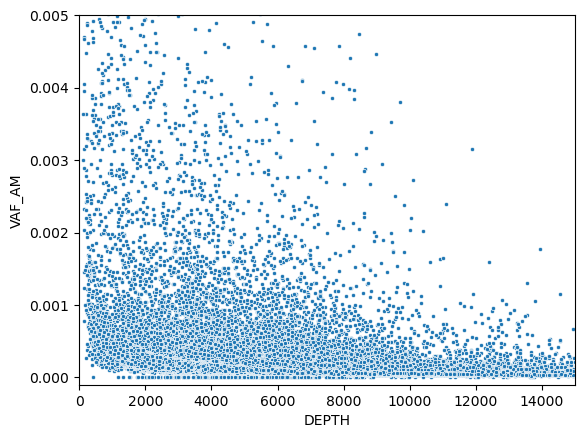

In [14]:
sns.scatterplot(data = somatic_maf_df,
                x = "DEPTH",
                y = "VAF_AM",
                #hue = "Protein_affecting",
                marker = '.'
               )
# plt.yscale('log')
# plt.xscale('log')
# plt.title(criteria)
plt.ylim(-0.0001,0.005)
plt.xlim(0,15000)

plt.show()

# 'VAF_distorsion', 'VAF_Ns', 'VAF_Ns_AM'